# Sesión 2 · Variables categóricas y numéricas
## House Prices — Advanced Regression Techniques

| | |
|---|---|
| **Equipo** | Israel González Huerta A01751433<br>Luis David Pozos Tamez A01800657<br>Adrián Proaño Bernal A01752615<br>Juan Pablo Solís Gómez A01800430<br>Karol Alexis Alvarado Davila A01751711 |
| **Fecha** | 21 de agosto de 2026 |
| **Objetivo** | Analizar las variables categóricas y numéricas de House Prices: distribución, cardinalidad, tendencia central, skewness, outliers y correlación con el target. |

---

> Usamos el mismo `train.csv` que descargaron en la sesión 1. Si no lo tienen, revisen las instrucciones de descarga en el notebook de la sesión anterior o del `README.md`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/train.csv')
print('Dataset cargado:', df.shape)

Dataset cargado: (1460, 81)


---
## PARTE 1

### 1.1 Categóricas · `value_counts()`

Antes de ver si una variable categórica se relaciona con el target, hay que saber cómo está distribuida ¿está balanceada o hay categorías dominantes?

In [2]:
df['Neighborhood'].value_counts()

Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
ClearCr     28
StoneBr     25
SWISU       25
MeadowV     17
Blmngtn     17
BrDale      16
Veenker     11
NPkVill      9
Blueste      2
Name: count, dtype: int64

### 1.2 Relación con el target. `groupby()` + `.mean()`

¿Cambia el precio promedio según el vecindario?

In [3]:
df.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False).round(0)

Neighborhood
NoRidge    335295.0
NridgHt    316271.0
StoneBr    310499.0
Timber     242247.0
Veenker    238773.0
Somerst    225380.0
ClearCr    212565.0
Crawfor    210625.0
CollgCr    197966.0
Blmngtn    194871.0
Gilbert    192855.0
NWAmes     189050.0
SawyerW    186556.0
Mitchel    156270.0
NAmes      145847.0
NPkVill    142694.0
SWISU      142591.0
Blueste    137500.0
Sawyer     136793.0
OldTown    128225.0
Edwards    128220.0
BrkSide    124834.0
BrDale     104494.0
IDOTRR     100124.0
MeadowV     98576.0
Name: SalePrice, dtype: float64

Las diferencias entre vecindarios son de decenas de miles de dólares. `Neighborhood` sí parece tener relación con `SalePrice`. Vale la pena verlo también con un boxplot para ver la distribución completa, no solo el promedio.

### 1.3 Boxplot por categoría

El boxplot muestra la distribución completa del target dentro de cada grupo: mediana, dispersión y outliers, no solo el promedio.

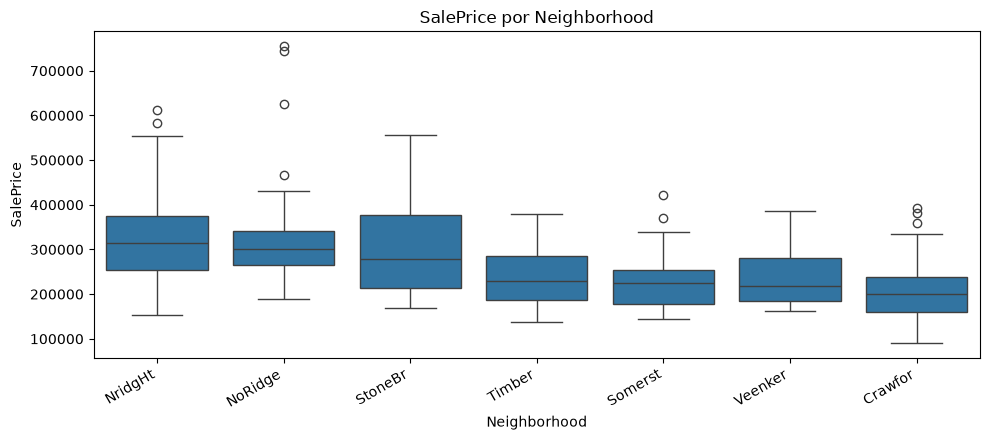

In [4]:
top_barrios = df.groupby('Neighborhood')['SalePrice'].median().nlargest(7).index

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.boxplot(data=df[df['Neighborhood'].isin(top_barrios)],
            x='Neighborhood', y='SalePrice', order=top_barrios, ax=ax)
ax.set_title('SalePrice por Neighborhood')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

Las medianas entre vecindarios son parecidas (~$265k–$290k) y los IQR se solapan bastante. `Neighborhood` por sí solo no separa limpiamente casas caras de baratas. Todos los vecindarios tienen outliers solo hacia arriba, nunca hacia abajo, primera señal del sesgo positivo de `SalePrice` también dentro de cada grupo, no solo en la distribución global. `OldTown` destaca con 3 outliers marcados (~$620k–$740k), más que el resto, candidata a revisar de cerca.

### 1.4 Tendencia central y dispersión

In [5]:
print(f"Media:   {df['SalePrice'].mean():,.0f}")
print(f"Mediana: {df['SalePrice'].median():,.0f}")
print(f"Std:     {df['SalePrice'].std():,.0f}")
print(f"Rango:   {df['SalePrice'].min():,.0f} - {df['SalePrice'].max():,.0f}")

Media:   180,921
Mediana: 163,000
Std:     79,443
Rango:   34,900 - 755,000


La media ($180,921) es mayor que la mediana ($163,000). Segunda señal de sesgo positivo.

### 1.5 Skewness

In [6]:
print(f"SalePrice skew: {df['SalePrice'].skew():.2f}")
print(f"GrLivArea skew: {df['GrLivArea'].skew():.2f}")

SalePrice skew: 1.88
GrLivArea skew: 1.37


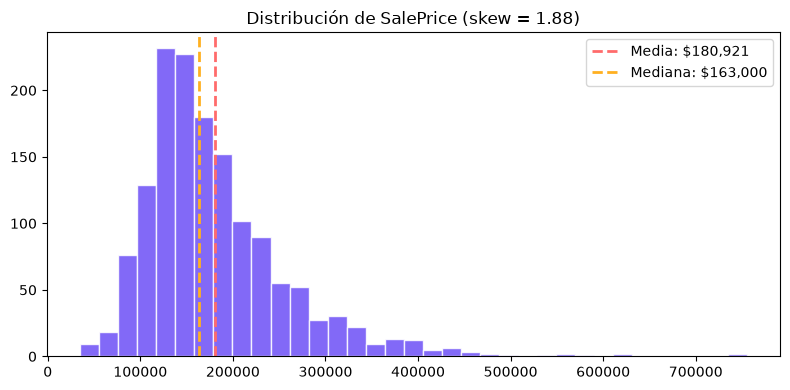

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['SalePrice'], bins=35, color='#6C4FF6', edgecolor='white', alpha=0.85)
ax.axvline(df['SalePrice'].mean(), color='#FF6B6B', linewidth=2, linestyle='--',
           label=f"Media: ${df['SalePrice'].mean():,.0f}")
ax.axvline(df['SalePrice'].median(), color='#FFB020', linewidth=2, linestyle='--',
           label=f"Mediana: ${df['SalePrice'].median():,.0f}")
ax.set_title(f"Distribución de SalePrice (skew = {df['SalePrice'].skew():.2f})")
ax.legend()
plt.tight_layout()
plt.show()

`SalePrice` tiene skew = 1.88 (|γ| > 1). Un sesgo positivo fuerte. `GrLivArea` en cambio tiene skew = 1.37, algo más simétrico.

### 1.6 Outliers · Regla de Tukey (1.5 × IQR)

In [8]:
Q1 = df['GrLivArea'].quantile(0.25)
Q3 = df['GrLivArea'].quantile(0.75)
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

outliers = df[(df['GrLivArea'] < lim_inf) | (df['GrLivArea'] > lim_sup)]

print(f'Q1={Q1:.0f}  Q3={Q3:.0f}  IQR={IQR:.0f}')
print(f'Límites: [{lim_inf:.0f}, {lim_sup:.0f}]')
print(f'Outliers encontrados: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)')

Q1=1130  Q3=1777  IQR=647
Límites: [159, 2748]
Outliers encontrados: 31 (2.1%)


> Aplicamos Tukey sobre `GrLivArea` (skew bajo) y no sobre `SalePrice` directamente, con su sesgo de 1.88, la regla generaría muchos falsos positivos en la cola derecha. Eso se corrige transformando primero.

### 1.7 Correlación con el target

In [9]:
num_cols = ['SalePrice', 'OverallQual', 'GrLivArea', 'YearBuilt', 'LotFrontage']
corr = df[num_cols].corr()

print(corr['SalePrice'].sort_values(ascending=False).round(2))

SalePrice      1.00
OverallQual    0.79
GrLivArea      0.71
YearBuilt      0.52
LotFrontage    0.35
Name: SalePrice, dtype: float64


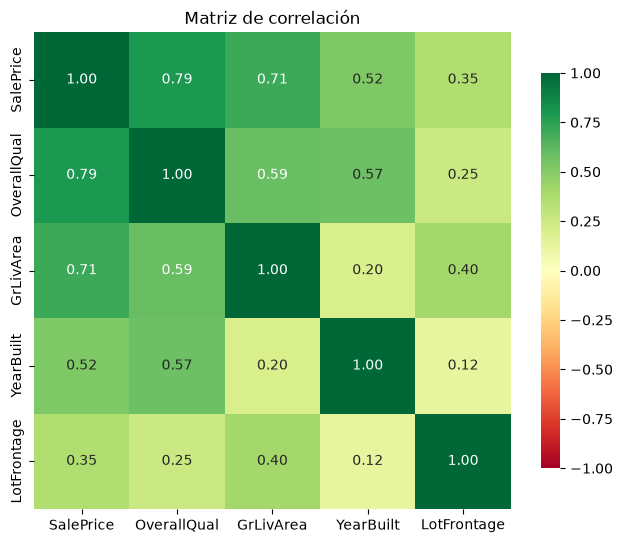

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', vmin=-1, vmax=1,
            ax=ax, square=True, cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de correlación')
plt.tight_layout()
plt.show()

`GrLivArea` (0.79) y `OverallQual` (0.71) son las más correlacionadas con `SalePrice` en esta muestra. `LotFrontage` prácticamente no tiene relación lineal (0.35), es candidata a descartar sin mucho análisis adicional según la estrategia de priorización que vimos en la presentación.

---
## PARTE 2 

*A partir de aquí trabajan solos (en equipo). Completen las celdas de código y respondan en las celdas de interpretación.*

**Entregable:** este notebook, con todas las celdas ejecutadas y las interpretaciones completadas.

> Documentación oficial de pandas: [pandas.pydata.org/docs](https://pandas.pydata.org/docs/reference/frame.html).

### 2.1 Tabla de contingencia · `pd.crosstab()`

`pd.crosstab()` no se explicó en detalle en la presentación, búsquenla en la documentación de pandas antes de usarla.

Primero, creamos una categoría de precio a partir de `SalePrice` (ya que `crosstab` funciona mejor entre dos variables categóricas):

In [11]:
# Creamos una categoría binaria a partir de la mediana
mediana = df['SalePrice'].median()
df['CategoriaPrecio'] = np.where(df['SalePrice'] >= mediana, 'Caro', 'Económico')

df[['SalePrice', 'CategoriaPrecio']].head()

,SalePrice,CategoriaPrecio
0,208500,Caro
1,181500,Caro
2,223500,Caro
3,140000,Económico
4,250000,Caro


In [12]:
# Posteriormente se crea una tabla de contingencia entre CentralAir y CategoriaPrecio
tabla_de_contingencia = pd.crosstab(df['CentralAir'], df['CategoriaPrecio'], margins=True)
tabla_de_contingencia

CategoriaPrecio,Caro,Económico,All
CentralAir,,,
N,7,88,95
Y,725,640,1365
All,732,728,1460


In [13]:
# Con normalize='index' obtenemos proporciones por fila en vez de conteos
tabla_de_contingencia_proporcion = pd.crosstab(df['CentralAir'], df['CategoriaPrecio'], margins=True, normalize='index')
tabla_de_contingencia_proporcion

CategoriaPrecio,Caro,Económico
CentralAir,,
N,0.073684,0.926316
Y,0.531136,0.468864
All,0.501370,0.498630


**Interpretación:**

*¿Las casas con aire acondicionado central (`CentralAir = 'Y'`) tienden más a estar en la categoría 'Caro'? ¿Qué proporción de las casas sin aire acondicionado caen en cada categoría?*

*Las casas con aire acondicionado central están divididas casi mitad y mitad entre caro y económico. El 53.1% de las casas con aire están en Caro, y el 46.8% de las casas con aire están en Económico. Donde sí hay una asociación más fuerte es en las casas sin aire acondicionado: el 92.6% de las casas que no tienen aire caen en la categoría Económico, y sólo 7.4% están en Caro. Es decir, aproximadamente 7 de las 95 casas en esta categoría son caras.*

### 2.2 Cardinalidad de todas las variables categóricas

Revisen la cardinalidad de **todas** las columnas categóricas del dataset, no solo `Neighborhood`.

In [14]:
categorical_cols = df.select_dtypes(include=['object']).columns.drop('CategoriaPrecio')
print(f'{len(categorical_cols)} de {df.shape[1] - 1}')

cardinalidad = df[categorical_cols].nunique().sort_values(ascending=False)
cardinalidad

43 de 81


C:\Users\lppl2\AppData\Local\Temp\ipykernel_33416\874961374.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.drop('CategoriaPrecio')


Neighborhood     25
Exterior2nd      16
Exterior1st      15
Condition1        9
SaleType          9
HouseStyle        8
RoofMatl          8
Condition2        8
Functional        7
BsmtFinType2      6
RoofStyle         6
BsmtFinType1      6
SaleCondition     6
Heating           6
Foundation        6
GarageType        6
ExterCond         5
LotConfig         5
MSZoning          5
GarageCond        5
GarageQual        5
HeatingQC         5
Electrical        5
BldgType          5
FireplaceQu       5
LandContour       4
LotShape          4
KitchenQual       4
MiscFeature       4
Fence             4
BsmtCond          4
ExterQual         4
BsmtExposure      4
BsmtQual          4
LandSlope         3
PoolQC            3
GarageFinish      3
PavedDrive        3
MasVnrType        3
Utilities         2
Alley             2
Street            2
CentralAir        2
dtype: int64

**Interpretación:**

*¿Alguna columna tiene cardinalidad sospechosamente alta (cercana al número de filas)? ¿Qué columna del dataset es? ¿Qué se debería de hacer con esta?*

*No hay ninguna cardinalidad sospechosa. La más alta es Neighborhood, pero está  muy lejos de las 1460 filas del dataset que podrían hacernos sospechar de que sea un identificador. La siguiente más alta es Exterior2nd, pero con 16 registros, tampoco es motivo alguno de preocupación.*

### 2.3 Boxplot de dos variables categóricas adicionales

Elijan **dos** variables categóricas del dataset (distintas a `Neighborhood`) y grafiquen su boxplot contra `SalePrice`.

MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64 



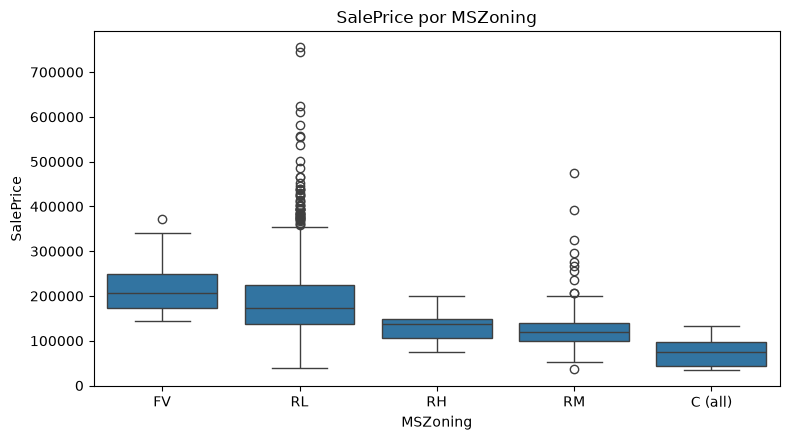

,count,median,mean
MSZoning,,,
FV,65,205950.0,214014.0
RL,1151,174000.0,191005.0
RH,16,136500.0,131558.0
RM,218,120500.0,126317.0
C (all),10,74700.0,74528.0


In [15]:
# Variable categórica 1
print(df['MSZoning'].value_counts(), '\n')

orden_zoning = df.groupby('MSZoning')['SalePrice'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=df, x='MSZoning', y='SalePrice', order=orden_zoning, ax=ax)
ax.set_title('SalePrice por MSZoning')
plt.tight_layout()
plt.show()

df.groupby('MSZoning')['SalePrice'].agg(['count', 'median', 'mean']).round(0).loc[orden_zoning]


LotShape
Reg    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64 



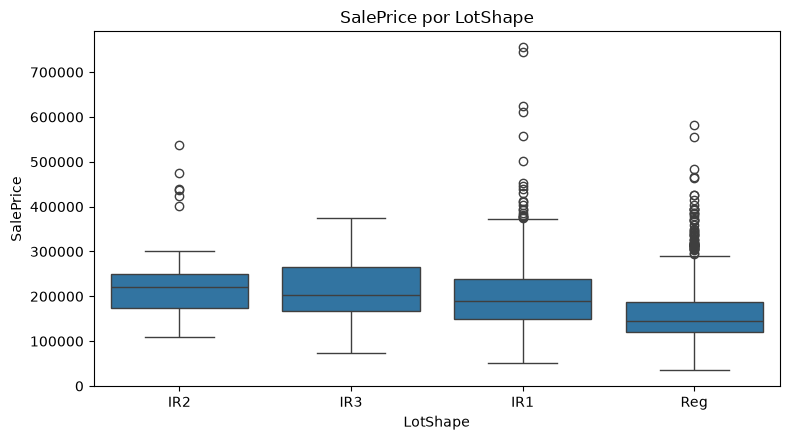

,count,median,mean
LotShape,,,
IR2,41,221000.0,239833.0
IR3,10,203570.0,216036.0
IR1,484,189000.0,206102.0
Reg,925,146000.0,164755.0


In [16]:
# Variable categórica 2
print(df['LotShape'].value_counts(), '\n')

orden_shape = df.groupby('LotShape')['SalePrice'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=df, x='LotShape', y='SalePrice', order=orden_shape, ax=ax)
ax.set_title('SalePrice por LotShape')
plt.tight_layout()
plt.show()

df.groupby('LotShape')['SalePrice'].agg(['count', 'median', 'mean']).round(0).loc[orden_shape]


**Interpretación:**

*Para cada una de las dos variables que eligieron: ¿parece haber una relación clara con SalePrice, o las distribuciones se ven muy parecidas entre categorías?*

*En MSZoning sí hay una relación clara. La mediana va de 205950 en FV hasta 74700 en C(all), casi 3 veces de diferencia, que es demasiado grande para explicarse solo por el azar de cómo cayeron las casas en cada grupo, sobre todo con muestras de ese tamaño. Si no hubiera relación, las dos medianas tendrían que haber salido casi iguales, y no salieron asi*

*En LotShape también hay relación, aunque más débil, no se puede concluir mucho. Como las cajas se solapan bastante, sabemos que dentro de cada categoría los precios siguen estando muy repartidos. Tampoco creemos que un terreno irregular valga más por ser irregular. Lo más probable es que los lotes irregulares estén en fraccionamientos más nuevos y caros, o sea que la relación es indirecta.*

### 2.4 Skewness de todas las variables numéricas

Calculen el skewness de todas las columnas numéricas a la vez (no solo `SalePrice` y `GrLivArea`) y ordénenlas de mayor a menor sesgo.

In [17]:
skewness_de_col_numericas = df.select_dtypes(include=[np.number]).skew().sort_values(ascending=False)

n_sesgadas = (skewness_de_col_numericas.abs() > 1).sum()
print(f'numericas: {len(skewness_de_col_numericas)}')
print(f'|skew| > 1: {n_sesgadas} ({n_sesgadas/len(skewness_de_col_numericas)*100:.0f}%)\n')

skewness_de_col_numericas

numericas: 38
|skew| > 1: 20 (53%)



MiscVal          24.476794
PoolArea         14.828374
LotArea          12.207688
3SsnPorch        10.304342
LowQualFinSF      9.011341
KitchenAbvGr      4.488397
BsmtFinSF2        4.255261
ScreenPorch       4.122214
BsmtHalfBath      4.103403
EnclosedPorch     3.089872
MasVnrArea        2.669084
OpenPorchSF       2.364342
LotFrontage       2.163569
SalePrice         1.882876
BsmtFinSF1        1.685503
WoodDeckSF        1.541376
TotalBsmtSF       1.524255
MSSubClass        1.407657
1stFlrSF          1.376757
GrLivArea         1.366560
BsmtUnfSF         0.920268
2ndFlrSF          0.813030
OverallCond       0.693067
TotRmsAbvGrd      0.676341
HalfBath          0.675897
Fireplaces        0.649565
BsmtFullBath      0.596067
OverallQual       0.216944
MoSold            0.212053
BedroomAbvGr      0.211790
GarageArea        0.179981
YrSold            0.096269
FullBath          0.036562
Id                0.000000
GarageCars       -0.342549
YearRemodAdd     -0.503562
YearBuilt        -0.613461
G

**Interpretación:**

*¿Qué variables tienen |skew| > 1? ¿Alguna las sorprendió?*

*20 de las 38 columnas numéricas lo pasan. Las más extremas son MiscVal (24.48), PoolArea (14.83), LotArea (12.21), 3SsnPorch (10.30) y LowQualFinSF (9.01). Como casi todas esas columnas miden cosas que la mayoría de las casas simplemente no tiene (alberca, porche de tres estaciones, extras miscelanos), sabemos que casi todos sus valores son 0 y que las poquitas casas que sí tienen algo son las que jalan toda la cola derecha. O sea que el skew ahí no describe una distribución rara, describe una columna casi vacía, y eso cambia qué se debería hacer con ellas: no es cosa de transformarlas, sino de preguntarse si aportan algo.*

*Lo que sí nos sorprendió fue LotArea (12.21). Como es una medida de superficie normal y no una columna de ceros, sabemos que su sesgo viene de otro lado.También nos llamó la atención que SalePrice (1.88) y GrLivArea (1.37) queden apenas a media tabla, cuando en la Parte 1 los tratamos como los casos sesgados del dataset.*

### 2.5 Matriz de correlación completa

En la demo solo usamos 5 columnas numéricas. Ahora calculen la matriz de correlación con **todas** las columnas numéricas del dataset.

In [18]:
matriz_de_correlacion_numericas = df.select_dtypes(include=[np.number]).corr()
print('dimensiones:', matriz_de_correlacion_numericas.shape)

matriz_de_correlacion_numericas

dimensiones: (38, 38)


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,1.000000,0.011156,-0.010601,-0.033226,-0.028365,0.012609,-0.012713,-0.021998,-0.050298,-0.005024,...,-0.029643,-0.000477,0.002889,-0.046635,0.001330,0.057044,-0.006242,0.021172,0.000712,-0.021917
MSSubClass,0.011156,1.000000,-0.386347,-0.139781,0.032628,-0.059316,0.027850,0.040581,0.022936,-0.069836,...,-0.012579,-0.006100,-0.012037,-0.043825,-0.026030,0.008283,-0.007683,-0.013585,-0.021407,-0.084284
LotFrontage,-0.010601,-0.386347,1.000000,0.426095,0.251646,-0.059213,0.123349,0.088866,0.193458,0.233633,...,0.088521,0.151972,0.010700,0.070029,0.041383,0.206167,0.003368,0.011200,0.007450,0.351799
LotArea,-0.033226,-0.139781,0.426095,1.000000,0.105806,-0.005636,0.014228,0.013788,0.104160,0.214103,...,0.171698,0.084774,-0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,-0.014261,0.263843
OverallQual,-0.028365,0.032628,0.251646,0.105806,1.000000,-0.091932,0.572323,0.550684,0.411876,0.239666,...,0.238923,0.308819,-0.113937,0.030371,0.064886,0.065166,-0.031406,0.070815,-0.027347,0.790982
OverallCond,0.012609,-0.059316,-0.059213,-0.005636,-0.091932,1.000000,-0.375983,0.073741,-0.128101,-0.046231,...,-0.003334,-0.032589,0.070356,0.025504,0.054811,-0.001985,0.068777,-0.003511,0.043950,-0.077856
YearBuilt,-0.012713,0.027850,0.123349,0.014228,0.572323,-0.375983,1.000000,0.592855,0.315707,0.249503,...,0.224880,0.188686,-0.387268,0.031355,-0.050364,0.004950,-0.034383,0.012398,-0.013618,0.522897
YearRemodAdd,-0.021998,0.040581,0.088866,0.013788,0.550684,0.073741,0.592855,1.000000,0.179618,0.128451,...,0.205726,0.226298,-0.193919,0.045286,-0.038740,0.005829,-0.010286,0.021490,0.035743,0.507101
MasVnrArea,-0.050298,0.022936,0.193458,0.104160,0.411876,-0.128101,0.315707,0.179618,1.000000,0.264736,...,0.159718,0.125703,-0.110204,0.018796,0.061466,0.011723,-0.029815,-0.005965,-0.008201,0.477493
BsmtFinSF1,-0.005024,-0.069836,0.233633,0.214103,0.239666,-0.046231,0.249503,0.128451,0.264736,1.000000,...,0.204306,0.111761,-0.102303,0.026451,0.062021,0.140491,0.003571,-0.015727,0.014359,0.386420


**Interpretación:**

*¿Cuáles son las 3 variables más correlacionadas con SalePrice en el dataset completo? Según la estrategia de priorización de la presentación, ¿en qué variables se enfocarían primero si tuvieran que elegir solo 5 para seguir explorando?*

*Con las 38 columnas numéricas, las 3 más correlacionadas con SalePrice son OverallQual (0.79), GrLivArea (0.71) y GarageCars (0.64). Notamos que en la celda 1.7 se mencionan invertidas: la de 0.79 es OverallQual y la de 0.71 es GrLivArea, según la salida de esa misma celda. Después vienen GarageArea (0.62), TotalBsmtSF (0.61) y 1stFlrSF (0.61).*

*Para elegir 5 no nos fuimos solo por el top de la lista. Como GarageArea y GarageCars están correlacionadas entre sí en 0.88, sabemos que las dos suben y bajan casi juntas, o sea que miden prácticamente lo mismo (qué tan grande es la cochera) y meter las dos no agrega información nueva, solo repite la que ya tenemos. Pasa igual con 1stFlrSF y TotalBsmtSF (0.82) y con TotRmsAbvGrd y GrLivArea (0.83), que es lógico porque una casa más grande tiene más cuartos. Entonces nos quedamos con OverallQual, GrLivArea, GarageCars, TotalBsmtSF y YearBuilt (0.52). Sacrificamos TotRmsAbvGrd, que tiene correlación un poquito más alta (0.53), a cambio de YearBuilt, porque como la antigüedad no está pegada a ninguna de las otras cuatro, sabemos que sí aporta algo distinto. Con eso cubrimos calidad, tamaño habitable, cochera, sótano y antigüedad sin repetir la misma señal cinco veces.*

---
## Resumen de hallazgos (conclusión del equipo)

| Pregunta | Respuesta del equipo |
|---|---|
| ¿`Neighborhood parece influir en `SalePrice`? | Sí. Neighborhood tiene un gran impacto en el precio de venta de una propiedad. Con las 25 categorías completas los promedios van desde $98,576 (MeadowV) hasta $335,295 (NoRidge), lo cual es un incremento de más del triple. Esto es consistente con la realidad observada, donde podemos ver propiedades similares en casi todas sus características, pero que tienen precios bastamente diferentes solo por el área en la que se encuentran. |
| ¿Cuál es la columna categórica con mayor cardinalidad (aparte de un ID)? | Neighborhood, con 25 categorías distintas (sección 2.2). Le sigue Exterior2nd con 16. Ninguna se acerca a las 1460 filas del dataset, así que no hay ninguna columna categórica que en realidad sea un identificador disfrazado. |
| ¿`SalePrice` tiene sesgo? ¿Positivo o negativo, y qué tan fuerte? | Sí, sesgo positivo y fuerte: skew = 1.88. Se ve también en que la media (\$180,921) es mayor que la mediana (\$163,000) y en que el histograma tiene una cola larga hacia la derecha, unas pocas casas muy caras jalan el promedio hacia arriba mientras que la mayoría se concentra en precios más bajos. |
| ¿Qué porcentaje de outliers encontraron en `GrLivArea`? | 2.1% (31 de 1460 casas), usando la regla de Tukey de 1.5×IQR sobre GrLivArea directamente (límites: [159, 2748]). Usamos GrLivArea y no SalePrice para esto porque el sesgo de SalePrice (1.88) infla artificialmente el conteo de outliers en la cola derecha. |
| ¿Cuáles son las 3 variables más correlacionadas con el target? | OverallQual (0.79), GrLivArea (0.71) y GarageCars (0.64), según la matriz de correlación completa de la sección 2.5. Muy cerca quedan GarageArea (0.62) y TotalBsmtSF (0.61), pero como GarageArea está muy correlacionada con GarageCars (0.88) básicamente repite la misma señal. |
| ¿Qué variable descartarían de entrada por baja correlación y baja variabilidad? | MiscVal. Además de tener una correlación lineal con SalePrice de apenas -0.02 (prácticamente nula) tiene una variabilidad demasiado baja, con el 96.4% de las filas con ceros. Coincide con lo que vimos en 2.4: su skew altísimo (24.48) no describe una distribución rara, sino una columna casi vacía que aporta poca información para predecir el precio. |